Analizar el siguiente EDA realizado sobre el dataser breast_cancer, el cual contiene características morfológicas de células obtenidas de imágenes digitalizadas.

In [ ]:
# Ejercicio Boosting - Victoria Gutiérrez

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

CSV_PATH = "breast_cancer.csv"  # <-- ajustar ruta si es necesario
df = pd.read_csv(CSV_PATH)
print("Shape del dataset:", df.shape)


Shape del dataset: (569, 31)


In [ ]:
df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,NaN,122.8,1001.0,0.11840,0.27760,0.3001,NaN,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,NaN,132.9,1326.0,0.08474,0.07864,NaN,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,NaN,0.2069,NaN,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              500 non-null    float64
 1   mean texture             488 non-null    float64
 2   mean perimeter           483 non-null    float64
 3   mean area                482 non-null    float64
 4   mean smoothness          497 non-null    float64
 5   mean compactness         478 non-null    float64
 6   mean concavity           491 non-null    float64
 7   mean concave points      486 non-null    float64
 8   mean symmetry            495 non-null    float64
 9   mean fractal dimension   491 non-null    float64
 10  radius error             484 non-null    float64
 11  texture error            487 non-null    float64
 12  perimeter error          493 non-null    float64
 13  area error               491 non-null    float64
 14  smoothness error         4

In [ ]:
X = df.drop(columns=["target"])
y = df["target"].astype(int)

print(f"\nFilas con >=1 nulo en TODO el dataset: {X.isna().any(axis=1).sum()} "
      f"({X.isna().any(axis=1).mean()*100:.2f}%)")


Filas con >=1 nulo en TODO el dataset: 562 (98.77%)


<Figure size 800x400 with 0 Axes>

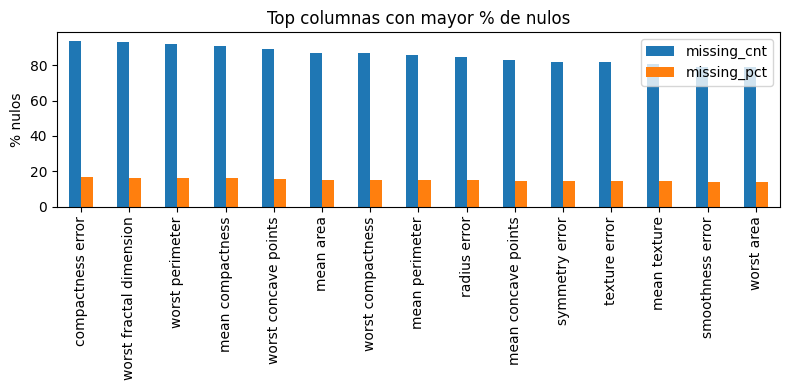

In [ ]:
plt.figure(figsize=(8,4))
eda_nulls.head(15).plot(kind="bar")
plt.title("Top columnas con mayor % de nulos")
plt.ylabel("% nulos")
plt.tight_layout()
plt.show()

Entrenar 60 modelos de XGBoost, incrementando la cantidad de árboles de a 10. El primer modelo tendrá 10 árboles y el último, 600.

Graficar la función de pérdida vs cantidad de árboles y elegir la cantidad óptima de n_estimators por la regla del codo. Reportar roc-auc del modelo elegido. Analizar los resultados

In [ ]:
# opcional usar estos parámetros

xgb_base = XGBClassifier(
    objective="binary:logistic",
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=1.0,
    n_estimators=1,     # lo variamos abajo
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
)

Usen este mismo dataset para entrenar un modelo con alguna otra técnica vista en clase (Random Forest, KNN, etc..)